## Model Interpretation — Customer Churn

### By:
Data Science Team

### Date:
2026-02-25

### Description:
Interpret the best trained model using:
- **Feature Importance** (model-native impurity-based)
- **Permutation Importance** (model-agnostic, on test set)
- **Partial Dependence Plots (PDP)** for top features
- **SHAP values** for local + global explanations (if shap is available)

## 📚 Import libraries

In [3]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

print("Python  :", sys.version)
print("Pandas  :", pd.__version__)

# Check SHAP availability
try:
    import shap

    SHAP_AVAILABLE = True
    print("SHAP    :", shap.__version__)
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP    : not installed — install with `pip install shap` to enable SHAP plots")

Python  : 3.12.12 (main, Feb 12 2026, 00:42:14) [Clang 21.1.4 ]
Pandas  : 2.3.3
SHAP    : 0.50.0


## 💾 Load model and data

In [4]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
MODELS_DIR = DATA_DIR / "06_models"
INPUT_DIR = DATA_DIR / "05_model_input"

model = joblib.load(MODELS_DIR / "best_model.pkl")
x_test = pd.read_parquet(INPUT_DIR / "x_test.parquet")
y_test = pd.read_parquet(INPUT_DIR / "y_test.parquet").squeeze()
x_train = pd.read_parquet(INPUT_DIR / "x_train.parquet")
y_train = pd.read_parquet(INPUT_DIR / "y_train.parquet").squeeze()

with open(MODELS_DIR / "feature_names.json") as f:
    feature_names = json.load(f)

with open(MODELS_DIR / "model_metadata.json") as f:
    metadata = json.load(f)

print(f"Model loaded : {metadata['model_name']}")
print(f"Test AUC-ROC : {metadata['test_metrics']['auc_roc']}")
print(f"Features     : {len(feature_names)}")
print(f"Test shape   : {x_test.shape}")

Model loaded : Logistic Regression (baseline)
Test AUC-ROC : 0.8443
Features     : 40
Test shape   : (1447, 40)


In [ ]:
from sklearn.pipeline import Pipeline

# If the saved model is a Pipeline, extract the final classifier and
# pre-transform the data so that SHAP / impurity-based importance work correctly.
if isinstance(model, Pipeline):
    estimator = model[-1]  # final step (the classifier)
    preprocessor = model[:-1]  # all steps before the classifier
    x_test_t = pd.DataFrame(preprocessor.transform(x_test), columns=x_test.columns)
    x_train_t = pd.DataFrame(preprocessor.transform(x_train), columns=x_train.columns)
    print(f"Pipeline detected — classifier: {type(estimator).__name__}")
else:
    estimator = model
    x_test_t = x_test
    x_train_t = x_train
    print(f"Plain estimator: {type(estimator).__name__}")

## 📊 Feature Importance

### 1️⃣ Model-native Importance (impurity-based)
Available for tree-based models (Random Forest, Gradient Boosting).

### 2️⃣ Permutation Importance (model-agnostic)

In [ ]:
TOP_N = 20

if hasattr(estimator, "feature_importances_"):
    importances = pd.Series(estimator.feature_importances_, index=feature_names)
    top_imp = importances.sort_values(ascending=False).head(TOP_N)

    fig, ax = plt.subplots(figsize=(10, 6))
    top_imp.sort_values().plot.barh(ax=ax, color="steelblue", edgecolor="black", alpha=0.8)
    ax.set_xlabel("Importance (mean decrease in impurity)")
    ax.set_title(f"Top {TOP_N} Feature Importances — {metadata['model_name']}", fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nTop {TOP_N} features:")
    for feat, imp in top_imp.items():
        print(f"  {feat:45s} {imp:.4f}")
else:
    print("Model does not expose feature_importances_ — skipping impurity-based plot.")
    if hasattr(estimator, "coef_"):
        coef = pd.Series(np.abs(estimator.coef_[0]), index=feature_names)
        top_imp = coef.sort_values(ascending=False).head(TOP_N)
        fig, ax = plt.subplots(figsize=(10, 6))
        top_imp.sort_values().plot.barh(ax=ax, color="steelblue", edgecolor="black", alpha=0.8)
        ax.set_xlabel("|Coefficient|")
        ax.set_title(
            f"Top {TOP_N} Features by |Coefficient| — {metadata['model_name']}", fontweight="bold"
        )
        plt.tight_layout()
        plt.show()

Model does not expose feature_importances_ — skipping impurity-based plot.


Computing permutation importance on test set …


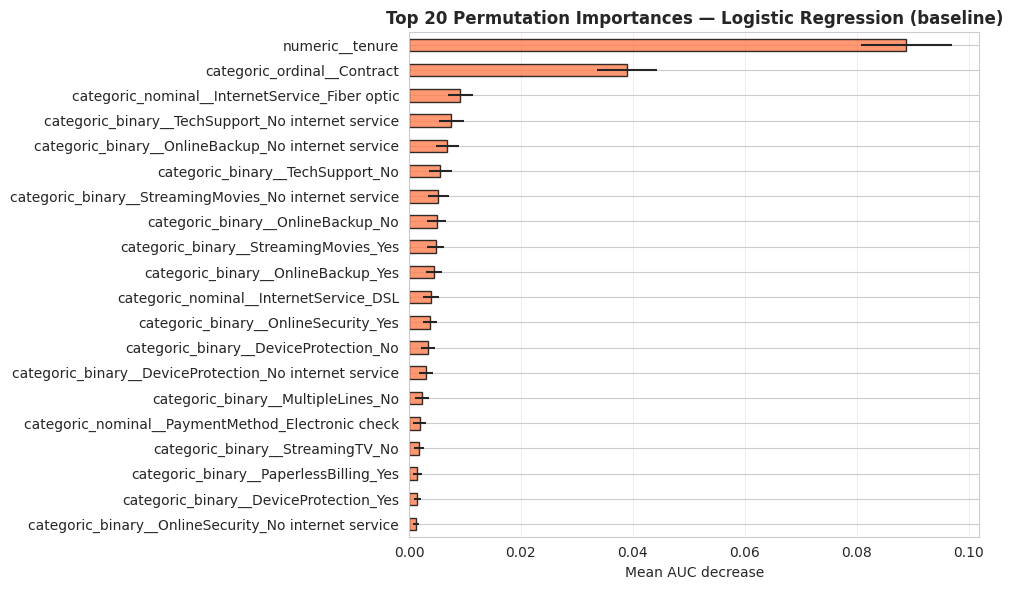


✅ Saved: /home/santi/Crum-CDPDN/data/08_reporting/feature_importance.csv


In [6]:
print("Computing permutation importance on test set …")
perm_result = permutation_importance(
    model, x_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring="roc_auc"
)

perm_imp = pd.Series(perm_result.importances_mean, index=feature_names)
perm_std = pd.Series(perm_result.importances_std, index=feature_names)
top_perm = perm_imp.sort_values(ascending=False).head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 6))
top_perm.sort_values().plot.barh(
    ax=ax,
    xerr=perm_std[top_perm.index].sort_values().values,
    color="coral",
    edgecolor="black",
    alpha=0.8,
)
ax.set_xlabel("Mean AUC decrease")
ax.set_title(f"Top {TOP_N} Permutation Importances — {metadata['model_name']}", fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Save feature importance to reporting
report_dir = DATA_DIR / "08_reporting"
report_dir.mkdir(parents=True, exist_ok=True)
perm_imp.sort_values(ascending=False).to_frame("permutation_importance").to_csv(
    report_dir / "feature_importance.csv"
)
print(f"\n✅ Saved: {report_dir / 'feature_importance.csv'}")

### 3️⃣ Partial Dependence Plots (PDP)

Shows the marginal effect of the top features on the predicted churn probability.

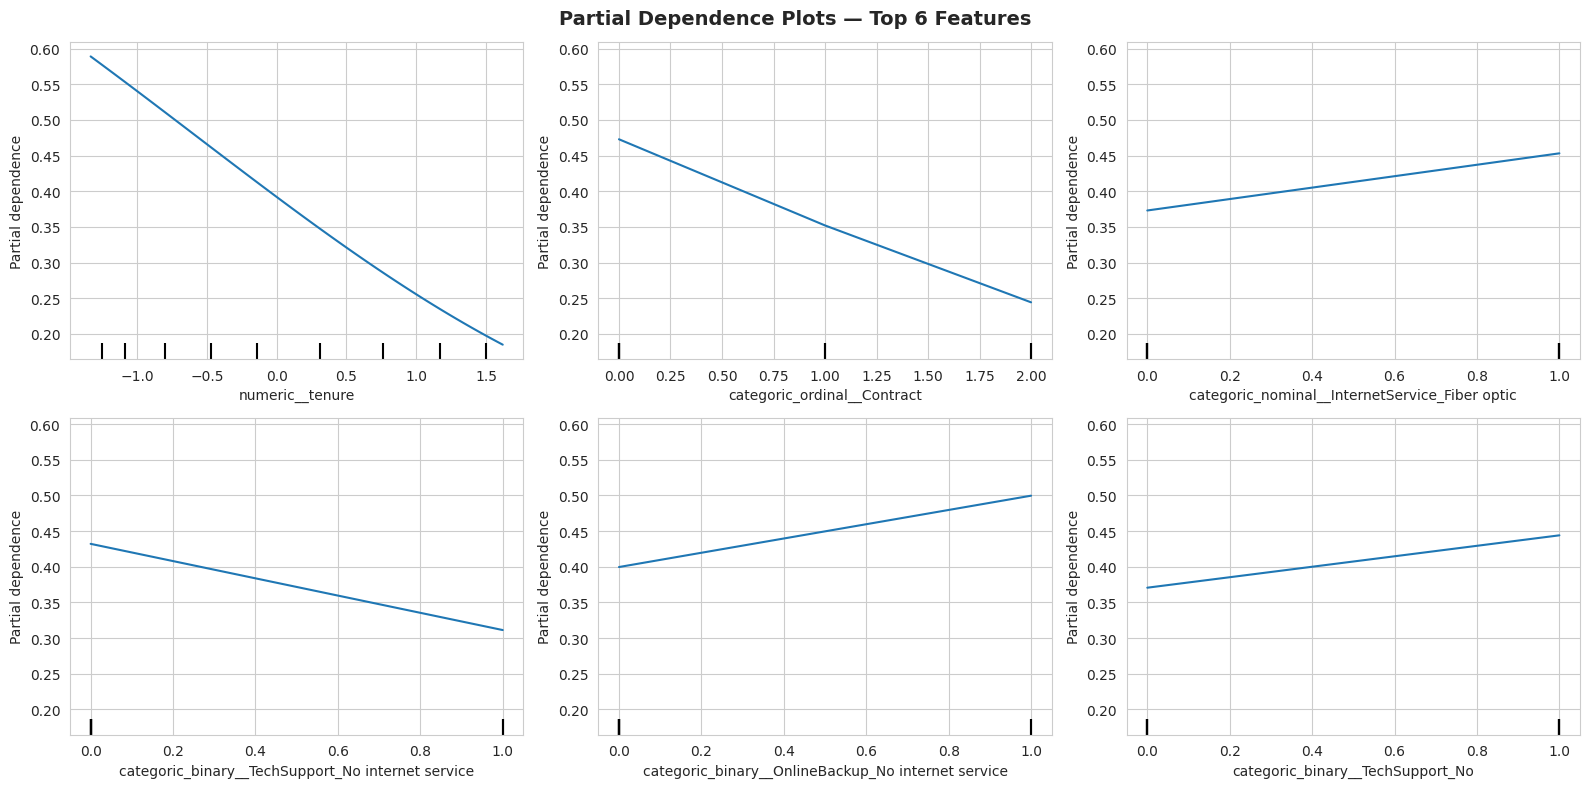

In [7]:
top_features_for_pdp = top_perm.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
PartialDependenceDisplay.from_estimator(
    model,
    x_test,
    top_features_for_pdp,
    ax=axes.flatten()[: len(top_features_for_pdp)],
    kind="average",
)
plt.suptitle("Partial Dependence Plots — Top 6 Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 4️⃣ SHAP Values (global + local)

In [ ]:
if SHAP_AVAILABLE:
    if hasattr(estimator, "feature_importances_"):
        explainer = shap.TreeExplainer(estimator)
        shap_vals = explainer.shap_values(x_test_t)
        # For binary classifiers, shap_values returns list [class0, class1]
        sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

        print("SHAP Summary Plot (bar):")
        shap.summary_plot(
            sv, x_test_t, feature_names=feature_names, plot_type="bar", show=True, max_display=TOP_N
        )

        print("\nSHAP Summary Plot (beeswarm):")
        shap.summary_plot(sv, x_test_t, feature_names=feature_names, show=True, max_display=TOP_N)

        # Local explanation — first churn example
        churn_idx = y_test[y_test == 1].index[0]
        loc = y_test.index.get_loc(churn_idx)
        print(f"\nLocal explanation for customer index {churn_idx}:")
        shap.waterfall_plot(
            shap.Explanation(
                values=sv[loc],
                base_values=explainer.expected_value[1]
                if isinstance(explainer.expected_value, list)
                else explainer.expected_value,
                data=x_test_t.iloc[loc].values,
                feature_names=feature_names,
            )
        )
    else:
        explainer = shap.LinearExplainer(estimator, x_train_t)
        shap_vals = explainer.shap_values(x_test_t)
        shap.summary_plot(
            shap_vals, x_test_t, feature_names=feature_names, show=True, max_display=TOP_N
        )
else:
    print("SHAP not available. Install it with: pip install shap")

InvalidModelError: An unknown model type was passed: <class 'sklearn.pipeline.Pipeline'>

## 📊 Analysis of Results and Conclusions

- **Impurity-based importance**: fast but can favour high-cardinality features.  
- **Permutation importance**: model-agnostic and evaluated on held-out test set — more reliable.  
- **PDP**: shows marginal effect on churn probability; non-linear relationships visible in tree models.  
- **SHAP**: provides both global (summary) and local (per-customer) explanations, enabling business storytelling.

## 💡 Proposals and Ideas
1. Compare SHAP rankings vs. permutation importance to validate feature selection.  
2. Use SHAP waterfall plots in the Streamlit demo for individual predictions.  
3. Apply ICE (Individual Conditional Expectation) plots alongside PDP for heterogeneous effects.

## 📖 References
- https://joserzapata.github.io/post/ciencia-datos-proyecto-python/6-interpretation/
- SHAP documentation: https://shap.readthedocs.io
- Scikit-learn inspection: https://scikit-learn.org/stable/modules/partial_dependence.html